In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import nltk

# NLTK tools
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

print("Libraries Imported Successfully")

Libraries Imported Successfully


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\JAHANGIR\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\JAHANGIR\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
# ==========================================
# Load Training Dataset
# ==========================================

train_df = pd.read_csv(
    "twitter_training.csv",
    header=None
)

# Add column names
train_df.columns = [
    "tweet_id",
    "topic",
    "sentiment",
    "text"
]

print("Training Dataset Shape:")
print(train_df.shape)

Training Dataset Shape:
(74682, 4)


In [3]:
# ==========================================
# Load Validation Dataset
# ==========================================

valid_df = pd.read_csv(
    "twitter_validation.csv",
    header=None
)

# Add column names
valid_df.columns = [
    "tweet_id",
    "topic",
    "sentiment",
    "text"
]

print("Validation Dataset Shape:")
print(valid_df.shape)

Validation Dataset Shape:
(1000, 4)


In [4]:
# ==========================================
# Display First 5 Rows
# ==========================================

train_df.head()

,tweet_id,topic,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [5]:
# ==========================================
# Dataset Information
# ==========================================

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   74682 non-null  int64 
 1   topic      74682 non-null  object
 2   sentiment  74682 non-null  object
 3   text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [6]:
# ==========================================
# Sentiment Distribution
# ==========================================

train_df['sentiment'].value_counts()

sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

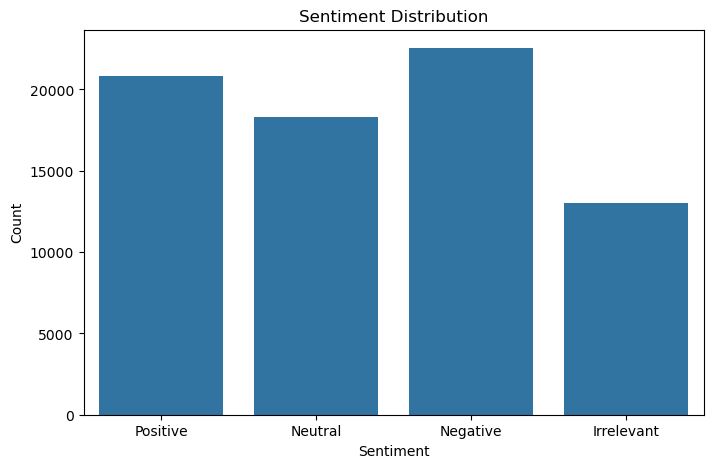

In [7]:
# ==========================================
# Sentiment Distribution Graph
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    x=train_df['sentiment']
)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.xticks(rotation=0)

# Save image
plt.savefig("sentiment_distribution.png")

plt.show()

In [8]:
# ==========================================
# Initialize NLP Tools
# ==========================================

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

print("NLP Tools Ready")

NLP Tools Ready


In [9]:
# ==========================================
# Text Cleaning Function
# ==========================================

def clean_text(text):

    # Convert to string
    text = str(text)

    # Convert lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\\S+|www\\S+', '', text)

    # Remove usernames
    text = re.sub(r'@\\w+', '', text)

    # Remove hashtags
    text = re.sub(r'#\\w+', '', text)

    # Remove numbers
    text = re.sub(r'\\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove short words
    words = [word for word in words if len(word) > 2]

    # Remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [10]:
# ==========================================
# Apply Text Cleaning
# ==========================================

train_df['clean_text'] = train_df['text'].apply(clean_text)

print("Text Cleaning Completed")

Text Cleaning Completed


In [11]:
# ==========================================
# Original vs Cleaned Text
# ==========================================

train_df[['text', 'clean_text']].head()

,text,clean_text
0,im getting on borderlands and i will murder yo...,imgettingonborderlandsandiwillmurderyouall
1,I am coming to the borders and I will kill you...,iamcomingtothebordersandiwillkillyouall
2,im getting on borderlands and i will kill you ...,imgettingonborderlandsandiwillkillyouall
3,im coming on borderlands and i will murder you...,imcomingonborderlandsandiwillmurderyouall
4,im getting on borderlands 2 and i will murder ...,imgettingonborderlandsandiwillmurderyoumeall


In [12]:
# ==========================================
# Remove Missing Values
# ==========================================

train_df.dropna(inplace=True)

print("Dataset Shape After Removing Missing Values:")
print(train_df.shape)

Dataset Shape After Removing Missing Values:
(73996, 5)


In [13]:
# ==========================================
# Remove Duplicate Rows
# ==========================================

train_df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:")
print(train_df.shape)

Dataset Shape After Removing Duplicates:
(71656, 5)


In [14]:
# ==========================================
# Final Sentiment Distribution
# ==========================================

train_df['sentiment'].value_counts()

sentiment
Negative      21698
Positive      19713
Neutral       17708
Irrelevant    12537
Name: count, dtype: int64

In [15]:
# ==========================================
# TF-IDF Feature Extraction
# ==========================================

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

X = tfidf.fit_transform(
    train_df['clean_text']
)

y = train_df['sentiment']

print("TF-IDF Feature Shape:")
print(X.shape)

TF-IDF Feature Shape:
(71656, 3177)


In [16]:
# ==========================================
# Split Dataset into Training and Testing Data
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

Training Data Shape:
(57324, 3177)

Testing Data Shape:
(14332, 3177)


# Machine Learning Model Training

In [17]:
# ==========================================
# Train Naive Bayes Model
# ==========================================

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:")
print(accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy:
0.36442924923248676


In [18]:
# ==========================================
# Train Support Vector Machine (SVM)
# ==========================================

svm_model = LinearSVC(C=10)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:")
print(accuracy_score(y_test, svm_pred))

SVM Accuracy:
0.3647781188947809


In [19]:
# ==========================================
# Train Logistic Regression Model
# ==========================================

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy:
0.36484789282723973


In [20]:
# ==========================================
# Model Accuracy Comparison
# ==========================================

results = pd.DataFrame({

    'Model': [
        'Naive Bayes',
        'SVM',
        'Logistic Regression'
    ],

    'Accuracy': [

        accuracy_score(y_test, nb_pred),

        accuracy_score(y_test, svm_pred),

        accuracy_score(y_test, lr_pred)
    ]
})

results

,Model,Accuracy
0,Naive Bayes,0.364429
1,SVM,0.364778
2,Logistic Regression,0.364848


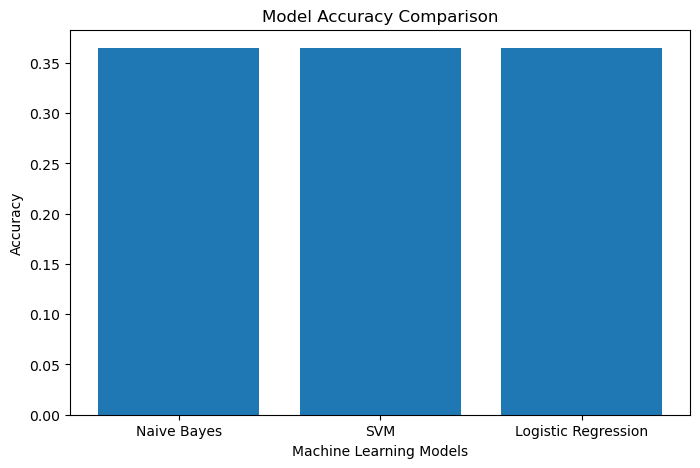

In [21]:
# ==========================================
# Accuracy Comparison Graph
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    results['Model'],
    results['Accuracy']
)

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

# Save image
plt.savefig("accuracy_comparison.png")

plt.show()

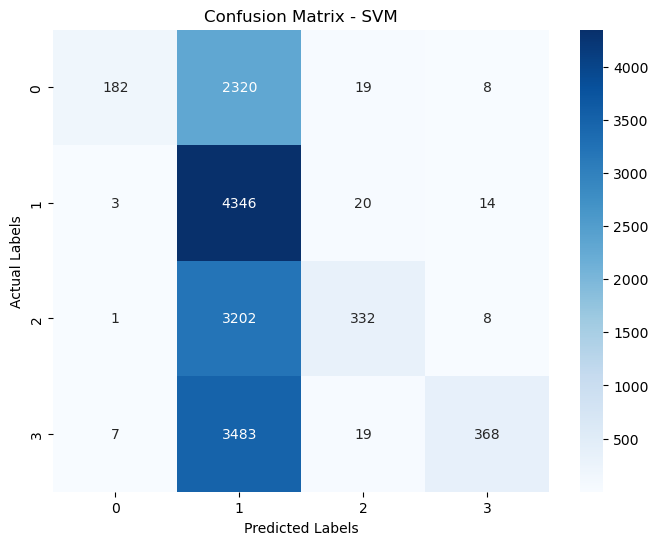

In [22]:
# ==========================================
# Confusion Matrix - SVM
# ==========================================

cm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - SVM")

plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")

# Save image
plt.savefig("confusion_matrix_svm.png")

plt.show()

In [23]:
# ==========================================
# Classification Report - SVM
# ==========================================

print(
    classification_report(
        y_test,
        svm_pred
    )
)

              precision    recall  f1-score   support

  Irrelevant       0.94      0.07      0.13      2529
    Negative       0.33      0.99      0.49      4383
     Neutral       0.85      0.09      0.17      3543
    Positive       0.92      0.09      0.17      3877

    accuracy                           0.36     14332
   macro avg       0.76      0.31      0.24     14332
weighted avg       0.73      0.36      0.26     14332



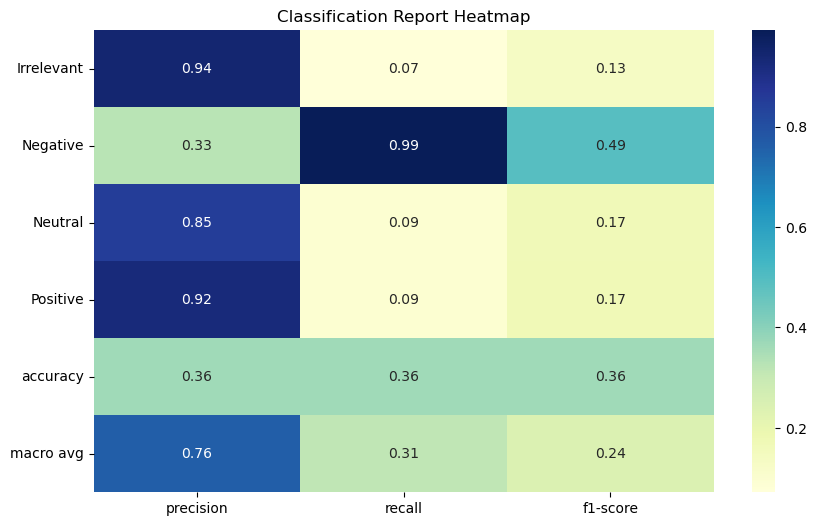

In [24]:
# ==========================================
# Visual Classification Report Heatmap
# ==========================================

report = classification_report(
    y_test,
    svm_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(10,6))

sns.heatmap(
    report_df.iloc[:-1, :-1],
    annot=True,
    cmap='YlGnBu',
    fmt='.2f'
)

plt.title("Classification Report Heatmap")

plt.yticks(rotation=0)

# Save image
plt.savefig("classification_report_heatmap.png")

plt.show()

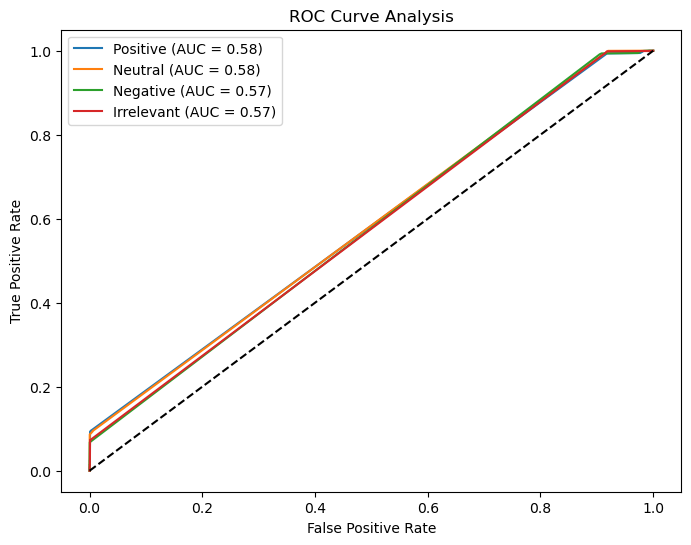

In [25]:
# ==========================================
# ROC Curve Analysis
# ==========================================

from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc

# Convert labels into binary format
classes = y.unique()

y_bin = label_binarize(
    y,
    classes=classes
)

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X,
    y_bin,
    test_size=0.2,
    random_state=42
)

# Train model
roc_model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000)
)

roc_model.fit(
    X_train_bin,
    y_train_bin
)

# Predict probabilities
y_score = roc_model.predict_proba(X_test_bin)

# Plot ROC Curves
plt.figure(figsize=(8,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{classes[i]} (AUC = {roc_auc:.2f})'
    )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Analysis")

plt.legend()

# Save image
plt.savefig("roc_curve.png")

plt.show()